# Task 3 — Resume-Safe Final Run After Kaggle 12-Hour Timeout

This version **does not repeat the completed Version 1 ablation or Final-GNN 5-fold CV**.
Those completed results are recovered from the Version 1 Kaggle log supplied by the user.
Only the still-required best-baseline 5-fold CV, final frozen-model training, held-out test,
plots, and artifact saving are executed.

**Why:** Kaggle Save & Run All has a hard 12-hour execution limit. Re-running the completed
GNN experiments wastes the first ~10.5 hours and causes the notebook to be killed again.


## 1. Load dataset, current Task-2 artifacts, and frozen split


In [1]:
# Cell 1 — Imports, reproducibility, and paths

import gc
import json
import math
import random
import re
import subprocess
import sys
import time
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

# Install only if unavailable.
for package, import_name in [
    ("torch-geometric", "torch_geometric"),
    ("xgboost", "xgboost"),
    ("lightgbm", "lightgbm"),
]:
    try:
        __import__(import_name)
    except ImportError:
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "-q", package],
            check=False
        )

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from scipy.stats import wilcoxon

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_selection import VarianceThreshold, mutual_info_regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GroupKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, RobustScaler, label_binarize
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight

import xgboost as xgb
import lightgbm as lgb

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, TensorDataset, DataLoader as TorchDataLoader

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as PyGLoader
from torch_geometric.nn import (
    GATConv,
    GCNConv,
    SAGEConv,
    global_max_pool,
    global_mean_pool,
)

RANDOM_STATE = 42

# ============================================================
# RESUME-SAFE RUNTIME CONTROL
# ============================================================
# The Version-1 log proves that all ablations and all 5 Final-GNN
# CV folds finished before the 12-hour timeout. Do NOT rerun them.
RUN_ABLATIONS = False
USE_RECOVERED_VERSION1_RESULTS = True
RUN_FIRST_GNN_CV = False

# Optional persistent resume input:
# If a previous SUCCESSFUL Kaggle notebook output containing
# cv_best_baseline_partial.csv is attached as an input, this notebook
# will detect it automatically and continue from the first unfinished fold.

def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

set_all_seeds(RANDOM_STATE)

device = "cuda" if torch.cuda.is_available() else "cpu"

# Edit FEATURE_INPUT only if your Kaggle filename is different.
FEATURE_INPUT = "/kaggle/input/datasets/tahu663/task2-baseline-all/putemg_window_feature_dataset_filtered_unthresholded (1).parquet"

OUTPUT_FOLDER = Path("/kaggle/working/task3_results")
MODELS_FOLDER = Path("/kaggle/working/models")
OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)
MODELS_FOLDER.mkdir(parents=True, exist_ok=True)

GESTURE_NAMES = {
    0: "Idle",
    1: "Fist",
    2: "Flexion",
    3: "Extension",
    6: "Pinch-Index",
    7: "Pinch-Middle",
    8: "Pinch-Ring",
    9: "Pinch-Small",
}

N_CHANNELS = 24
METRICS_7 = ["MAV", "RMS", "STD", "VAR", "WL", "ZC", "SSC"]
N_METRICS = len(METRICS_7)

print("Device:", device)
print("Task-3 output folder:", OUTPUT_FOLDER)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 36.0 MB/s eta 0:00:00
Device: cuda
Task-3 output folder: /kaggle/working/task3_results


In [2]:
# Cell 2 — Resolve CURRENT Task-2 artifacts safely

def find_unique_file(filename, roots=(Path("/kaggle/working"), Path("/kaggle/input"))):
    candidates = []
    for root in roots:
        if not root.exists():
            continue
        direct = root / filename
        if direct.exists():
            candidates.append(direct)
        if root.name == "input":
            candidates.extend(root.rglob(filename))

    candidates = sorted(set(p.resolve() for p in candidates), key=lambda p: str(p))

    if not candidates:
        raise FileNotFoundError(
            f"Could not find '{filename}' under /kaggle/working or /kaggle/input."
        )

    if len(candidates) > 1:
        raise RuntimeError(
            f"Multiple files named '{filename}' were found.\n"
            + "\n".join(str(p) for p in candidates)
            + "\nAttach only the current artifact folder or replace the filename "
              "with an explicit full path in this cell."
        )

    return candidates[0]


# Resolve feature parquet.
feature_request = Path(FEATURE_INPUT)
if feature_request.is_absolute():
    FEATURE_PATH = feature_request
    assert FEATURE_PATH.exists(), f"Feature file not found: {FEATURE_PATH}"
else:
    try:
        FEATURE_PATH = find_unique_file(FEATURE_INPUT)
    except FileNotFoundError:
        # Safe fallback for a Kaggle-renamed current filtered parquet.
        pattern_matches = []
        input_root = Path("/kaggle/input")
        if input_root.exists():
            pattern_matches.extend(
                input_root.rglob("putemg_window_feature_dataset_filtered_unthresholded*.parquet")
            )
        pattern_matches = sorted(set(pattern_matches), key=lambda p: str(p))
        if len(pattern_matches) != 1:
            raise RuntimeError(
                "Could not uniquely identify the current filtered/unthresholded parquet.\n"
                + "\n".join(str(p) for p in pattern_matches)
            )
        FEATURE_PATH = pattern_matches[0]

feature_df = pd.read_parquet(FEATURE_PATH)

# Find split_info.json that explicitly matches the current feature filename.
split_candidates = []
for root in [Path("/kaggle/working"), Path("/kaggle/input")]:
    if not root.exists():
        continue
    candidates = [root / "split_info.json"] if (root / "split_info.json").exists() else []
    if root.name == "input":
        candidates += list(root.rglob("split_info.json"))

    for p in candidates:
        try:
            with open(p, "r") as f:
                info = json.load(f)
            recorded_name = Path(str(info.get("feature_file", ""))).name
            recorded_used = Path(str(info.get("feature_path_used", ""))).name
            if FEATURE_PATH.name in {recorded_name, recorded_used}:
                split_candidates.append(p.resolve())
        except Exception:
            pass

split_candidates = sorted(set(split_candidates), key=lambda p: str(p))

if len(split_candidates) != 1:
    raise RuntimeError(
        "Could not uniquely match the current feature parquet to one split_info.json.\n"
        f"Feature: {FEATURE_PATH}\n"
        "Matching split candidates:\n"
        + "\n".join(str(p) for p in split_candidates)
    )

SPLIT_PATH = split_candidates[0]
ARTIFACT_DIR = SPLIT_PATH.parent

BASELINE_RESULTS_PATH = ARTIFACT_DIR / "baseline_results.csv"
BASELINE_CONFIGS_PATH = ARTIFACT_DIR / "baseline_selected_configs.json"

assert BASELINE_RESULTS_PATH.exists(), (
    f"Current baseline_results.csv not found beside split_info.json: "
    f"{BASELINE_RESULTS_PATH}"
)
assert BASELINE_CONFIGS_PATH.exists(), (
    f"Current baseline_selected_configs.json not found beside split_info.json: "
    f"{BASELINE_CONFIGS_PATH}"
)

print("Feature parquet :", FEATURE_PATH)
print("Split info      :", SPLIT_PATH)
print("Baseline results:", BASELINE_RESULTS_PATH)
print("Baseline configs:", BASELINE_CONFIGS_PATH)


Feature parquet : /kaggle/input/datasets/tahu663/task2-baseline-all/putemg_window_feature_dataset_filtered_unthresholded (1).parquet
Split info      : /kaggle/input/datasets/tahu663/task2-baseline-all/split_info.json
Baseline results: /kaggle/input/datasets/tahu663/task2-baseline-all/baseline_results.csv
Baseline configs: /kaggle/input/datasets/tahu663/task2-baseline-all/baseline_selected_configs.json


In [3]:
# Cell 3 — Load split, identify current best baseline, and reconstruct partitions

required_cols = {"subject_id", "label"}
assert required_cols.issubset(feature_df.columns)

with open(SPLIT_PATH, "r") as f:
    split_info = json.load(f)

required_split_keys = {
    "train_subjects",
    "val_subjects",
    "test_subjects",
    "feat_cols",
    "label_classes",
}
missing = required_split_keys - set(split_info)
assert not missing, f"split_info.json missing keys: {sorted(missing)}"

train_subjects = [int(s) for s in split_info["train_subjects"]]
val_subjects = [int(s) for s in split_info["val_subjects"]]
test_subjects = [int(s) for s in split_info["test_subjects"]]
dev_subjects = sorted(train_subjects + val_subjects)

assert set(train_subjects).isdisjoint(val_subjects)
assert set(train_subjects).isdisjoint(test_subjects)
assert set(val_subjects).isdisjoint(test_subjects)
assert set(dev_subjects).isdisjoint(test_subjects)

dataset_subjects = set(int(s) for s in feature_df["subject_id"].unique())
assert set(dev_subjects).union(test_subjects) == dataset_subjects

train_df = feature_df[feature_df["subject_id"].isin(train_subjects)].copy().reset_index(drop=True)
val_df = feature_df[feature_df["subject_id"].isin(val_subjects)].copy().reset_index(drop=True)
dev_df = feature_df[feature_df["subject_id"].isin(dev_subjects)].copy().reset_index(drop=True)
test_df = feature_df[feature_df["subject_id"].isin(test_subjects)].copy().reset_index(drop=True)

baseline_df = pd.read_csv(BASELINE_RESULTS_PATH)
baseline_df["Macro-F1"] = pd.to_numeric(baseline_df["Macro-F1"], errors="coerce")
baseline_df = baseline_df[baseline_df["Macro-F1"].notna()].copy()
assert not baseline_df.empty

best_baseline_row = baseline_df.loc[baseline_df["Macro-F1"].idxmax()]
best_baseline_name = str(best_baseline_row["Model"]).strip()
best_baseline_task2_f1 = float(best_baseline_row["Macro-F1"])

with open(BASELINE_CONFIGS_PATH, "r") as f:
    baseline_selected_configs = json.load(f)

best_baseline_config = baseline_selected_configs.get(best_baseline_name, {})

expected_labels = [int(x) for x in split_info["label_classes"]]
assert sorted(int(x) for x in feature_df["label"].unique()) == sorted(expected_labels)

print(f"Dataset: {feature_df.shape[0]:,} rows x {feature_df.shape[1]} columns")
print(f"Task-2 train: {len(train_subjects)} subjects / {len(train_df):,} windows")
print(f"Task-2 val  : {len(val_subjects)} subjects / {len(val_df):,} windows")
print(f"Frozen test : {len(test_subjects)} subjects / {len(test_df):,} windows")
print(
    f"Task-2 best baseline by validation Macro-F1: "
    f"{best_baseline_name} ({best_baseline_task2_f1:.4f})"
)
print("Loaded baseline config:", best_baseline_config)


Dataset: 619,479 rows x 200 columns
Task-2 train: 31 subjects / 435,797 windows
Task-2 val  : 6 subjects / 85,277 windows
Frozen test : 7 subjects / 98,405 windows
Task-2 best baseline by validation Macro-F1: MLP (PyTorch) (0.7398)
Loaded baseline config: {'hidden_dims': [256, 128, 64], 'dropout': 0.3, 'optimizer': 'adamw', 'lr': 0.001, 'weight_decay': 0.0001, 'scheduler': 'plateau', 'class_weight_alpha': 0.0, 'batch_size': 1024, 'max_epochs': 60, 'patience': 12, 'selected_epoch': 2}


In [4]:
# Cell 4 — Required 5-fold subject-grouped partition of the 37 development subjects

N_FOLDS = 5
gkf = GroupKFold(n_splits=N_FOLDS)

row_idx = np.arange(len(dev_df))
groups = dev_df["subject_id"].to_numpy()
folds = []

for fold_id, (tr_idx, va_idx) in enumerate(gkf.split(row_idx, groups=groups), start=1):
    tr_subjects = sorted(int(x) for x in dev_df.iloc[tr_idx]["subject_id"].unique())
    va_subjects = sorted(int(x) for x in dev_df.iloc[va_idx]["subject_id"].unique())

    assert set(tr_subjects).isdisjoint(va_subjects)

    tr_labels = set(int(x) for x in dev_df.iloc[tr_idx]["label"].unique())
    va_labels = set(int(x) for x in dev_df.iloc[va_idx]["label"].unique())
    assert tr_labels == set(expected_labels), f"Fold {fold_id}: train fold misses a class"
    assert va_labels == set(expected_labels), f"Fold {fold_id}: val fold misses a class"

    folds.append((tr_idx, va_idx, tr_subjects, va_subjects))

    print(
        f"Fold {fold_id}: train {len(tr_subjects)} subjects / {len(tr_idx):,} windows | "
        f"val {len(va_subjects)} subjects / {len(va_idx):,} windows"
    )

all_outer_val_subjects = sorted(
    s for _, _, _, va_subjects in folds for s in va_subjects
)
assert all_outer_val_subjects == dev_subjects

print("5-fold subject partition verified.")


Fold 1: train 30 subjects / 422,031 windows | val 7 subjects / 99,043 windows
Fold 2: train 29 subjects / 408,548 windows | val 8 subjects / 112,526 windows
Fold 3: train 29 subjects / 409,792 windows | val 8 subjects / 111,282 windows
Fold 4: train 30 subjects / 421,940 windows | val 7 subjects / 99,134 windows
Fold 5: train 30 subjects / 421,985 windows | val 7 subjects / 99,089 windows
5-fold subject partition verified.


## 2. Feature preparation and leakage-safe preprocessing


In [5]:
# Cell 5 — Current 168-feature preprocessing

FEAT_PAT_7 = re.compile(r"EMG_\d+_(MAV|RMS|STD|VAR|WL|ZC|SSC)", re.I)

feat_cols_7 = [
    c for c in split_info["feat_cols"]
    if FEAT_PAT_7.fullmatch(c)
]

assert len(feat_cols_7) == 168
assert all(c in feature_df.columns for c in feat_cols_7)

expected_order = [
    f"EMG_{ch}_{metric}"
    for metric in METRICS_7
    for ch in range(1, N_CHANNELS + 1)
]

assert [c.upper() for c in feat_cols_7] == [c.upper() for c in expected_order], (
    "Feature order is not metric-major; 24 x 7 node reshape would be wrong."
)


def preprocess_split(fit_df, transform_df):
    # Every learned transform is fitted on fit_df only.
    X_fit_raw = fit_df[feat_cols_7].to_numpy(dtype=np.float32)
    X_transform_raw = transform_df[feat_cols_7].to_numpy(dtype=np.float32)

    assert np.isfinite(X_fit_raw).all()
    assert np.isfinite(X_transform_raw).all()

    vt = VarianceThreshold(threshold=0.0)
    X_fit_vt = vt.fit_transform(X_fit_raw)
    X_transform_vt = vt.transform(X_transform_raw)

    # Current Task-2 data retained all 168 features.
    assert X_fit_vt.shape[1] == 168, (
        f"VarianceThreshold retained {X_fit_vt.shape[1]}/168 features; "
        "the fixed 24 x 7 node reshape is no longer valid."
    )

    scaler = RobustScaler()
    X_fit = scaler.fit_transform(X_fit_vt).astype(np.float32)
    X_transform = scaler.transform(X_transform_vt).astype(np.float32)

    le = LabelEncoder()
    y_fit = le.fit_transform(fit_df["label"].to_numpy())

    unseen = set(transform_df["label"]) - set(fit_df["label"])
    assert not unseen, f"Transform split contains unseen labels: {unseen}"

    y_transform = le.transform(transform_df["label"].to_numpy())
    assert [int(x) for x in le.classes_] == expected_labels

    return {
        "X_fit": X_fit,
        "X_transform": X_transform,
        "y_fit": y_fit,
        "y_transform": y_transform,
        "vt": vt,
        "scaler": scaler,
        "le": le,
    }


def to_node_features(X):
    assert X.shape[1] == N_CHANNELS * N_METRICS
    return X.reshape(-1, N_METRICS, N_CHANNELS).transpose(0, 2, 1)


## 3. Graph construction and GNN model setup


In [6]:
# Cell 6 — Leakage-safe graph construction: MI, Pearson, or no inter-electrode graph
#
# DTF/MVAR is intentionally NOT fabricated here:
# DTF requires the raw multichannel time-series samples inside each window.
# The current Task-3 input is the already-aggregated 168-feature parquet.

score_matrix_cache = {}


def _subject_key(fit_df):
    return tuple(sorted(int(x) for x in fit_df["subject_id"].unique()))


def get_channel_score_matrix(X_fit_nodes, fit_df, method):
    """
    Score matrix is calculated from FIT/TRAINING subjects only.
    For MI and Pearson we use the MAV node feature, matching the current project design.

    For MI, the row-wise estimates are kept as computed so top-k selection follows
    the same rule as the current Task-2 MI-GraphSAGE notebook. Numerical weights
    are symmetrised only after topology is selected.
    """
    assert method in {"mi", "pearson"}

    key = (_subject_key(fit_df), method)
    if key in score_matrix_cache:
        return score_matrix_cache[key].copy()

    ch_mav = X_fit_nodes[:, :, 0]

    if method == "pearson":
        score = np.abs(np.corrcoef(ch_mav.T)).astype(np.float32)

    else:
        score = np.zeros((N_CHANNELS, N_CHANNELS), dtype=np.float32)

        for i in range(N_CHANNELS):
            score[i] = mutual_info_regression(
                ch_mav,
                ch_mav[:, i],
                random_state=RANDOM_STATE,
            ).astype(np.float32)

    np.fill_diagonal(score, 0.0)
    score = np.nan_to_num(score, nan=0.0, posinf=0.0, neginf=0.0)

    assert score.shape == (N_CHANNELS, N_CHANNELS)
    assert np.isfinite(score).all()

    score_matrix_cache[key] = score.copy()
    return score


def build_graph(
    X_fit_nodes,
    fit_df,
    graph_method="mi",
    top_k=4,
    edge_weight_mode="binary",
):
    """
    graph_method:
      - 'mi'      : top-k Mutual Information graph
      - 'pearson' : top-k absolute Pearson-correlation graph
      - 'none'    : no inter-electrode edges (direct graph-effect ablation)

    edge_weight_mode:
      - 'binary' : topology only
      - 'score'  : MI/Pearson strength where supported by the GNN layer
    """
    assert graph_method in {"mi", "pearson", "none"}
    assert edge_weight_mode in {"binary", "score"}

    if graph_method == "none":
        edge_index = torch.empty((2, 0), dtype=torch.long)
        edge_weight = torch.empty((0,), dtype=torch.float32)

        return {
            "method": "none",
            "top_k": None,
            "edge_weight_mode": "binary",
            "score_matrix": np.zeros((N_CHANNELS, N_CHANNELS), dtype=np.float32),
            "adjacency": np.zeros((N_CHANNELS, N_CHANNELS), dtype=np.float32),
            "edge_index": edge_index,
            "edge_weight": edge_weight,
            "n_directed_edges": 0,
            "degree_min": 0,
            "degree_max": 0,
            "degree_mean": 0.0,
        }

    assert 1 <= int(top_k) < N_CHANNELS

    score = get_channel_score_matrix(
        X_fit_nodes,
        fit_df,
        graph_method,
    )

    topology = np.zeros((N_CHANNELS, N_CHANNELS), dtype=bool)

    # IMPORTANT: top-k is selected from each row BEFORE symmetrising.
    # This matches the current Task-2 MI-GraphSAGE topology rule.
    for i in range(N_CHANNELS):
        row = score[i].copy()
        row[i] = -np.inf
        neighbours = np.argsort(row)[-int(top_k):]
        topology[i, neighbours] = True

    # Add reverse edges: symmetric union.
    topology = np.logical_or(topology, topology.T)
    np.fill_diagonal(topology, False)

    # Numerical weights should be symmetric on this undirected electrode graph.
    symmetric_score = np.maximum(score, score.T)

    if edge_weight_mode == "binary":
        adjacency = topology.astype(np.float32)
    else:
        adjacency = np.where(
            topology,
            symmetric_score,
            0.0
        ).astype(np.float32)

    rows, cols = np.nonzero(topology)

    edge_index = torch.tensor(
        np.stack([rows, cols]),
        dtype=torch.long
    )
    edge_weight = torch.tensor(
        adjacency[rows, cols],
        dtype=torch.float32
    )

    assert edge_index.shape[0] == 2
    assert len(rows) > 0
    assert int(edge_index.min()) >= 0
    assert int(edge_index.max()) < N_CHANNELS

    degrees = topology.sum(axis=1)

    return {
        "method": graph_method,
        "top_k": int(top_k),
        "edge_weight_mode": edge_weight_mode,
        "score_matrix": score,
        "adjacency": adjacency,
        "edge_index": edge_index,
        "edge_weight": edge_weight,
        "n_directed_edges": int(edge_index.shape[1]),
        "degree_min": int(degrees.min()),
        "degree_max": int(degrees.max()),
        "degree_mean": float(degrees.mean()),
    }


In [7]:
# Cell 7 — Lazy PyG dataset and flexible GNN
#
# The lazy dataset avoids materialising hundreds of thousands of duplicated
# torch_geometric.Data objects in RAM.

class EMGGraphDataset(Dataset):
    def __init__(self, X_nodes, y, edge_index, edge_weight):
        self.X_nodes = X_nodes
        self.y = y
        self.edge_index = edge_index
        self.edge_weight = edge_weight

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return Data(
            x=torch.as_tensor(self.X_nodes[idx], dtype=torch.float32),
            edge_index=self.edge_index,
            edge_attr=self.edge_weight.unsqueeze(1),
            y=torch.tensor(int(self.y[idx]), dtype=torch.long),
        )


class FlexGNN(nn.Module):
    """
    Default settings reproduce the CURRENT Task-2 MI-GraphSAGE architecture:
      SAGEConv 7->64
      SAGEConv 64->128
      mean + max pooling
      Linear 256->128
      ReLU + Dropout
      Linear 128->8
    """

    def __init__(
        self,
        in_dim,
        hidden_dims,
        n_classes,
        variant="sage",
        dropout=0.3,
        use_batchnorm=False,
        pooling="mean_max",
        gat_heads=4,
    ):
        super().__init__()

        assert variant in {"sage", "gcn", "gat"}
        assert pooling in {"mean_max", "mean", "max"}

        self.variant = variant
        self.pooling = pooling
        self.dropout = float(dropout)

        dims = [in_dim] + list(hidden_dims)

        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()

        for d_in, d_out in zip(dims[:-1], dims[1:]):
            if variant == "sage":
                conv = SAGEConv(d_in, d_out)
            elif variant == "gcn":
                conv = GCNConv(d_in, d_out)
            else:
                conv = GATConv(
                    d_in,
                    d_out,
                    heads=gat_heads,
                    concat=False,
                    edge_dim=1,
                )

            self.convs.append(conv)
            self.bns.append(
                nn.BatchNorm1d(d_out)
                if use_batchnorm
                else nn.Identity()
            )

        last_dim = dims[-1]
        pooled_dim = last_dim * 2 if pooling == "mean_max" else last_dim

        self.fc1 = nn.Linear(pooled_dim, 128)
        self.fc2 = nn.Linear(128, n_classes)

    def _message_passing(self, conv, x, edge_index, edge_weight):
        if self.variant == "sage":
            # SAGEConv uses topology only.
            return conv(x, edge_index)

        if self.variant == "gcn":
            return conv(
                x,
                edge_index,
                edge_weight=edge_weight if edge_weight.numel() else None,
            )

        edge_attr = (
            edge_weight.unsqueeze(1)
            if edge_weight.numel()
            else None
        )
        return conv(x, edge_index, edge_attr=edge_attr)

    def forward(self, x, edge_index, edge_weight, batch):
        for conv, bn in zip(self.convs, self.bns):
            x = self._message_passing(
                conv,
                x,
                edge_index,
                edge_weight
            )
            x = F.relu(bn(x))

        if self.pooling == "mean_max":
            x = torch.cat(
                [
                    global_mean_pool(x, batch),
                    global_max_pool(x, batch),
                ],
                dim=1,
            )
        elif self.pooling == "mean":
            x = global_mean_pool(x, batch)
        else:
            x = global_max_pool(x, batch)

        x = F.relu(self.fc1(x))
        x = F.dropout(x, p=self.dropout, training=self.training)

        return F.log_softmax(self.fc2(x), dim=1)


In [8]:
# Cell 8 — Metrics and GNN train/evaluate helpers

def full_metrics(y_true, y_pred, y_score=None):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    out = {
        "Accuracy": float(accuracy_score(y_true, y_pred)),
        "Balanced Accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "Macro Precision": float(
            precision_score(y_true, y_pred, average="macro", zero_division=0)
        ),
        "Macro Recall": float(
            recall_score(y_true, y_pred, average="macro", zero_division=0)
        ),
        "Macro-F1": float(
            f1_score(y_true, y_pred, average="macro", zero_division=0)
        ),
        "Weighted Precision": float(
            precision_score(y_true, y_pred, average="weighted", zero_division=0)
        ),
        "Weighted Recall": float(
            recall_score(y_true, y_pred, average="weighted", zero_division=0)
        ),
        "Weighted-F1": float(
            f1_score(y_true, y_pred, average="weighted", zero_division=0)
        ),
        "MCC": float(matthews_corrcoef(y_true, y_pred)),
    }

    if y_score is not None:
        y_score = np.asarray(y_score)
        y_bin = label_binarize(
            y_true,
            classes=np.arange(len(expected_labels))
        )

        roc_values = []
        ap_values = []

        for i in range(len(expected_labels)):
            if len(np.unique(y_bin[:, i])) < 2:
                continue
            roc_values.append(
                roc_auc_score(y_bin[:, i], y_score[:, i])
            )
            ap_values.append(
                average_precision_score(y_bin[:, i], y_score[:, i])
            )

        out["ROC-AUC"] = float(np.mean(roc_values)) if roc_values else float("nan")
        out["PR-AUC"] = float(np.mean(ap_values)) if ap_values else float("nan")

    return out


def make_gnn_loader(dataset, batch_size, shuffle):
    return PyGLoader(
        dataset,
        batch_size=int(batch_size),
        shuffle=bool(shuffle),
        num_workers=0,
    )


def predict_gnn(model, loader):
    model.eval()

    y_true = []
    y_pred = []
    y_score = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)

            out = model(
                batch.x,
                batch.edge_index,
                batch.edge_attr.squeeze(1),
                batch.batch,
            )

            y_true.append(batch.y.cpu().numpy())
            y_pred.append(out.argmax(dim=1).cpu().numpy())
            y_score.append(torch.exp(out).cpu().numpy())

    return (
        np.concatenate(y_true),
        np.concatenate(y_pred),
        np.concatenate(y_score),
    )


def train_gnn_split(
    fit_df,
    validation_df,
    cfg,
    seed=RANDOM_STATE,
    verbose=False,
):
    """
    Development/CV training:
    - preprocessing fits only on fit_df
    - graph builds only from fit_df
    - validation_df is used for checkpoint selection
    """
    set_all_seeds(seed)

    prep = preprocess_split(fit_df, validation_df)

    X_fit_nodes = to_node_features(prep["X_fit"])
    X_val_nodes = to_node_features(prep["X_transform"])

    graph = build_graph(
        X_fit_nodes,
        fit_df,
        graph_method=cfg["graph_method"],
        top_k=cfg.get("top_k", 4),
        edge_weight_mode=cfg.get("edge_weight_mode", "binary"),
    )

    train_ds = EMGGraphDataset(
        X_fit_nodes,
        prep["y_fit"],
        graph["edge_index"],
        graph["edge_weight"],
    )
    val_ds = EMGGraphDataset(
        X_val_nodes,
        prep["y_transform"],
        graph["edge_index"],
        graph["edge_weight"],
    )

    train_loader = make_gnn_loader(
        train_ds,
        cfg.get("batch_size", 512),
        True
    )
    val_loader = make_gnn_loader(
        val_ds,
        cfg.get("batch_size", 512),
        False
    )

    model = FlexGNN(
        in_dim=N_METRICS,
        hidden_dims=cfg.get("hidden_dims", [64, 128]),
        n_classes=len(expected_labels),
        variant=cfg.get("variant", "sage"),
        dropout=cfg.get("dropout", 0.3),
        use_batchnorm=cfg.get("use_batchnorm", False),
        pooling=cfg.get("pooling", "mean_max"),
    ).to(device)

    if cfg.get("use_class_weight", True):
        cw = compute_class_weight(
            "balanced",
            classes=np.unique(prep["y_fit"]),
            y=prep["y_fit"],
        )
        loss_weight = torch.tensor(
            cw,
            dtype=torch.float32,
            device=device,
        )
    else:
        loss_weight = None

    loss_fn = nn.NLLLoss(weight=loss_weight)

    lr = float(cfg.get("lr", 1e-3))
    wd = float(cfg.get("weight_decay", 1e-4))
    optimizer_name = cfg.get("optimizer", "adamw")

    if optimizer_name == "adamw":
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=lr,
            weight_decay=wd,
        )
    elif optimizer_name == "adam":
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=lr,
            weight_decay=wd,
        )
    else:
        raise ValueError(f"Unsupported optimizer: {optimizer_name}")

    scheduler_name = cfg.get("scheduler", "none")

    if scheduler_name == "none":
        scheduler = None
    elif scheduler_name == "plateau":
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="max",
            factor=0.5,
            patience=5,
        )
    elif scheduler_name == "step":
        scheduler = torch.optim.lr_scheduler.StepLR(
            optimizer,
            step_size=10,
            gamma=0.5,
        )
    else:
        raise ValueError(f"Unsupported scheduler: {scheduler_name}")

    max_epochs = int(cfg.get("epochs", 100))
    patience = int(cfg.get("patience", 20))

    best_f1 = -np.inf
    best_epoch = None
    best_state = None
    patience_counter = 0
    history = []

    t0 = time.time()

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_loss_sum = 0.0

        for batch in train_loader:
            batch = batch.to(device)

            optimizer.zero_grad(set_to_none=True)

            out = model(
                batch.x,
                batch.edge_index,
                batch.edge_attr.squeeze(1),
                batch.batch,
            )

            loss = loss_fn(out, batch.y)

            if not torch.isfinite(loss):
                raise RuntimeError(
                    f"Non-finite GNN loss at epoch {epoch}"
                )

            loss.backward()
            optimizer.step()

            train_loss_sum += float(loss.item())

        y_val, pred_val, score_val = predict_gnn(
            model,
            val_loader
        )

        val_macro_f1 = f1_score(
            y_val,
            pred_val,
            average="macro",
            zero_division=0,
        )

        if scheduler_name == "plateau":
            scheduler.step(val_macro_f1)
        elif scheduler_name == "step":
            scheduler.step()

        if val_macro_f1 > best_f1 + 1e-8:
            best_f1 = float(val_macro_f1)
            best_epoch = int(epoch)
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            patience_counter = 0
        else:
            patience_counter += 1

        history.append({
            "epoch": int(epoch),
            "train_loss": train_loss_sum / max(len(train_loader), 1),
            "val_macro_f1": float(val_macro_f1),
            "lr": float(optimizer.param_groups[0]["lr"]),
        })

        if verbose and (
            epoch == 1
            or epoch % 10 == 0
            or patience_counter >= patience
        ):
            print(
                f"epoch {epoch:03d} | "
                f"val Macro-F1={val_macro_f1:.4f} | "
                f"best={best_f1:.4f} | "
                f"patience={patience_counter}/{patience}"
            )

        if patience_counter >= patience:
            break

    assert best_state is not None
    assert best_epoch is not None

    model.load_state_dict(best_state)

    y_val, pred_val, score_val = predict_gnn(
        model,
        val_loader
    )

    metrics = full_metrics(
        y_val,
        pred_val,
        score_val
    )

    metrics["Best epoch"] = int(best_epoch)
    metrics["Epochs run"] = int(len(history))
    metrics["Train time (s)"] = float(time.time() - t0)

    artifacts = {
        "vt": prep["vt"],
        "scaler": prep["scaler"],
        "le": prep["le"],
        "graph": graph,
        "best_state": best_state,
        "history": history,
    }

    del train_loader, val_loader, train_ds, val_ds
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return metrics, model, artifacts


def evaluate_gnn_dataframe(
    model,
    eval_df,
    artifacts,
    batch_size=512,
):
    # Fit nothing here.
    X_raw = eval_df[feat_cols_7].to_numpy(dtype=np.float32)

    assert np.isfinite(X_raw).all(), (
        "Evaluation data contains NaN or Inf values."
    )
    X_vt = artifacts["vt"].transform(X_raw)
    X_scaled = artifacts["scaler"].transform(X_vt).astype(np.float32)
    y = artifacts["le"].transform(eval_df["label"].to_numpy())

    X_nodes = to_node_features(X_scaled)
    graph = artifacts["graph"]

    ds = EMGGraphDataset(
        X_nodes,
        y,
        graph["edge_index"],
        graph["edge_weight"],
    )
    loader = make_gnn_loader(ds, batch_size, False)

    y_true, y_pred, y_score = predict_gnn(
        model,
        loader
    )

    metrics = full_metrics(
        y_true,
        y_pred,
        y_score
    )

    del ds, loader
    gc.collect()

    return metrics, y_true, y_pred, y_score


In [9]:
# Cell 9 — Task-2 baseline reproduction helpers
#
# The best baseline is selected from CURRENT baseline_results.csv.
# Its saved Task-2 configuration is reused rather than silently reverting to defaults.

def canonical_baseline_name(name):
    token = re.sub(r"[^a-z0-9]+", " ", str(name).lower()).strip()

    aliases = {
        "logistic regression": "Logistic Regression",
        "lda": "LDA",
        "svm rbf": "SVM (RBF)",
        "svm": "SVM (RBF)",
        "k nn k 5": "k-NN (k=5)",
        "knn": "k-NN (k=5)",
        "decision tree": "Decision Tree",
        "random forest": "Random Forest",
        "gradient boosting": "Gradient Boosting",
        "xgboost": "XGBoost",
        "lightgbm": "LightGBM",
        "mlp pytorch": "MLP (PyTorch)",
        "mlp": "MLP (PyTorch)",
        "1d cnn pytorch": "1D-CNN (PyTorch)",
        "1d cnn": "1D-CNN (PyTorch)",
    }

    if token not in aliases:
        raise ValueError(f"Unsupported Task-2 baseline name: {name!r}")

    return aliases[token]


class Task2MLP(nn.Module):
    def __init__(self, in_dim, n_classes, dropout=0.3):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(min(dropout, 0.2)),

            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        return self.net(x)


class Task2CNN1D(nn.Module):
    def __init__(self, n_metrics, n_classes):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(n_metrics, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        return self.fc(self.conv(x))


def make_tensor_loader(
    X,
    y,
    batch_size=1024,
    shuffle=True,
    cnn=False,
):
    X_tensor = torch.tensor(
        X,
        dtype=torch.float32
    )

    if cnn:
        X_tensor = X_tensor.reshape(
            -1,
            N_METRICS,
            N_CHANNELS
        )

    ds = TensorDataset(
        X_tensor,
        torch.tensor(y, dtype=torch.long)
    )

    return TorchDataLoader(
        ds,
        batch_size=int(batch_size),
        shuffle=bool(shuffle),
    )


def predict_torch_baseline(model, loader):
    model.eval()

    ys = []
    preds = []
    scores = []

    with torch.no_grad():
        for xb, yb in loader:
            logits = model(xb.to(device))

            ys.append(yb.numpy())
            preds.append(
                logits.argmax(dim=1).cpu().numpy()
            )
            scores.append(
                torch.softmax(logits, dim=1).cpu().numpy()
            )

    return (
        np.concatenate(ys),
        np.concatenate(preds),
        np.concatenate(scores),
    )


def subject_class_balanced_subset(
    fit_df,
    y,
    max_total,
    seed,
):
    rng = np.random.default_rng(seed)

    subject_ids = fit_df["subject_id"].to_numpy()
    y = np.asarray(y)

    pairs = [
        (s, c)
        for s in np.unique(subject_ids)
        for c in np.unique(y)
    ]

    quota = max(1, int(max_total) // len(pairs))
    chosen = []

    for subject_id, class_id in pairs:
        idx = np.flatnonzero(
            (subject_ids == subject_id)
            & (y == class_id)
        )

        if len(idx):
            chosen.extend(
                rng.choice(
                    idx,
                    size=min(quota, len(idx)),
                    replace=False
                ).tolist()
            )

    chosen = np.asarray(
        sorted(set(chosen)),
        dtype=int
    )

    if len(chosen) > int(max_total):
        chosen = rng.choice(
            chosen,
            size=int(max_total),
            replace=False
        )

    return chosen


def train_task2_baseline_split(
    fit_df,
    validation_df,
    baseline_name,
    saved_config,
    seed=RANDOM_STATE,
    verbose=False,
):
    name = canonical_baseline_name(baseline_name)
    cfg = dict(saved_config or {})

    set_all_seeds(seed)

    prep = preprocess_split(
        fit_df,
        validation_df
    )

    X_fit = prep["X_fit"]
    X_val = prep["X_transform"]
    y_fit = prep["y_fit"]
    y_val = prep["y_transform"]

    # ---------------- PyTorch baselines ----------------
    if name in {
        "MLP (PyTorch)",
        "1D-CNN (PyTorch)",
    }:
        is_cnn = name == "1D-CNN (PyTorch)"

        batch_size = int(
            cfg.get("batch_size", 1024)
        )

        train_loader = make_tensor_loader(
            X_fit,
            y_fit,
            batch_size,
            True,
            is_cnn,
        )
        val_loader = make_tensor_loader(
            X_val,
            y_val,
            batch_size,
            False,
            is_cnn,
        )

        cw = compute_class_weight(
            "balanced",
            classes=np.unique(y_fit),
            y=y_fit,
        )

        alpha = float(
            cfg.get(
                "class_weight_alpha",
                1.0 if is_cnn else 0.0
            )
        )

        softened = np.power(cw, alpha)

        loss_weight = (
            None
            if alpha == 0.0
            else torch.tensor(
                softened,
                dtype=torch.float32,
                device=device,
            )
        )

        loss_fn = nn.CrossEntropyLoss(
            weight=loss_weight
        )

        if is_cnn:
            model = Task2CNN1D(
                N_METRICS,
                len(expected_labels)
            ).to(device)
        else:
            model = Task2MLP(
                X_fit.shape[1],
                len(expected_labels),
                dropout=float(cfg.get("dropout", 0.3)),
            ).to(device)

        optimizer_name = cfg.get(
            "optimizer",
            "adam" if is_cnn else "adamw"
        )

        lr = float(cfg.get("lr", 1e-3))
        wd = float(cfg.get("weight_decay", 1e-4))

        if optimizer_name == "adamw":
            optimizer = torch.optim.AdamW(
                model.parameters(),
                lr=lr,
                weight_decay=wd,
            )
        else:
            optimizer = torch.optim.Adam(
                model.parameters(),
                lr=lr,
                weight_decay=wd,
            )

        scheduler_name = cfg.get(
            "scheduler",
            "step" if is_cnn else "plateau"
        )

        if scheduler_name == "plateau":
            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer,
                mode="max",
                factor=0.5,
                patience=4,
            )
        elif scheduler_name == "step":
            scheduler = torch.optim.lr_scheduler.StepLR(
                optimizer,
                step_size=int(cfg.get("step_size", 10)),
                gamma=float(cfg.get("gamma", 0.5)),
            )
        else:
            scheduler = None

        max_epochs = int(
            cfg.get(
                "max_epochs",
                50 if is_cnn else 60
            )
        )
        patience = int(
            cfg.get(
                "patience",
                15 if is_cnn else 12
            )
        )

        best_f1 = -np.inf
        best_state = None
        best_epoch = None
        patience_counter = 0

        t0 = time.time()

        for epoch in range(1, max_epochs + 1):
            model.train()

            for xb, yb in train_loader:
                xb = xb.to(device)
                yb = yb.to(device)

                optimizer.zero_grad(set_to_none=True)

                loss = loss_fn(
                    model(xb),
                    yb
                )

                loss.backward()
                optimizer.step()

            y_check, pred_check, _ = predict_torch_baseline(
                model,
                val_loader
            )

            val_f1 = f1_score(
                y_check,
                pred_check,
                average="macro",
                zero_division=0,
            )

            if scheduler_name == "plateau":
                scheduler.step(val_f1)
            elif scheduler_name == "step":
                scheduler.step()

            if val_f1 > best_f1 + 1e-8:
                best_f1 = float(val_f1)
                best_epoch = int(epoch)
                best_state = {
                    k: v.detach().cpu().clone()
                    for k, v in model.state_dict().items()
                }
                patience_counter = 0
            else:
                patience_counter += 1

            if verbose and (
                epoch == 1
                or epoch % 5 == 0
                or patience_counter >= patience
            ):
                print(
                    f"{name} epoch {epoch:02d}: "
                    f"val Macro-F1={val_f1:.4f}, "
                    f"best={best_f1:.4f}"
                )

            if patience_counter >= patience:
                break

        assert best_state is not None

        model.load_state_dict(best_state)

        y_true, y_pred, y_score = predict_torch_baseline(
            model,
            val_loader
        )

        metrics = full_metrics(
            y_true,
            y_pred,
            y_score
        )

        metrics["Best epoch"] = int(best_epoch)
        metrics["Train time (s)"] = float(
            time.time() - t0
        )

        artifacts = {
            "vt": prep["vt"],
            "scaler": prep["scaler"],
            "le": prep["le"],
            "kind": "torch",
            "name": name,
            "cnn": is_cnn,
            "best_state": best_state,
            "config": cfg,
        }

        return metrics, model, artifacts

    # ---------------- sklearn / boosted-tree baselines ----------------

    model_X = X_fit
    model_y = y_fit
    fit_kwargs = {}

    if name == "Logistic Regression":
        model = LogisticRegression(
            solver=cfg.get("solver", "saga"),
            max_iter=int(cfg.get("max_iter", 3000)),
            tol=float(cfg.get("tol", 1e-3)),
            class_weight=cfg.get("class_weight", "balanced"),
            random_state=seed,
        )

    elif name == "LDA":
        model = LinearDiscriminantAnalysis(
            solver="lsqr",
            shrinkage="auto",
        )

    elif name == "SVM (RBF)":
        max_subset = int(cfg.get("max_subset", 60000))

        idx = subject_class_balanced_subset(
            fit_df,
            y_fit,
            max_subset,
            seed,
        )

        model_X = X_fit[idx]
        model_y = y_fit[idx]

        model = SVC(
            kernel="rbf",
            C=float(cfg.get("C", 10.0)),
            gamma=cfg.get("gamma", "scale"),
            class_weight=cfg.get("class_weight", "balanced"),
            probability=False,
            cache_size=3000,
            random_state=seed,
        )

    elif name == "k-NN (k=5)":
        model = KNeighborsClassifier(
            n_neighbors=int(cfg.get("n_neighbors", 5)),
            weights=cfg.get("weights", "uniform"),
            n_jobs=-1,
        )

    elif name == "Decision Tree":
        model = DecisionTreeClassifier(
            max_depth=cfg.get("max_depth", 20),
            class_weight=cfg.get("class_weight", "balanced"),
            random_state=seed,
        )

    elif name == "Random Forest":
        model = RandomForestClassifier(
            n_estimators=int(cfg.get("n_estimators", 400)),
            max_depth=cfg.get("max_depth", 30),
            random_state=seed,
            n_jobs=-1,
        )

    elif name == "Gradient Boosting":
        max_subset = int(cfg.get("max_subset", 100000))

        if len(X_fit) > max_subset:
            model_X, _, model_y, _ = train_test_split(
                X_fit,
                y_fit,
                train_size=max_subset,
                stratify=y_fit,
                random_state=seed,
            )

        model = GradientBoostingClassifier(
            n_estimators=int(cfg.get("n_estimators", 100)),
            max_depth=int(cfg.get("max_depth", 5)),
            learning_rate=float(cfg.get("learning_rate", 0.1)),
            random_state=seed,
        )

        fit_kwargs["sample_weight"] = compute_sample_weight(
            "balanced",
            y=model_y,
        )

    elif name == "XGBoost":
        model = xgb.XGBClassifier(
            n_estimators=int(cfg.get("n_estimators", 300)),
            max_depth=int(cfg.get("max_depth", 6)),
            learning_rate=float(cfg.get("learning_rate", 0.05)),
            eval_metric="mlogloss",
            random_state=seed,
            n_jobs=-1,
            tree_method="hist",
        )

    elif name == "LightGBM":
        model = lgb.LGBMClassifier(
            n_estimators=int(cfg.get("n_estimators", 200)),
            max_depth=int(cfg.get("max_depth", 6)),
            learning_rate=float(cfg.get("learning_rate", 0.1)),
            class_weight=cfg.get("class_weight", "balanced"),
            random_state=seed,
            n_jobs=-1,
            verbose=-1,
        )

    else:
        raise ValueError(name)

    t0 = time.time()
    model.fit(
        model_X,
        model_y,
        **fit_kwargs
    )
    train_time = time.time() - t0

    y_pred = model.predict(X_val)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_val)
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_val)
    else:
        y_score = None

    metrics = full_metrics(
        y_val,
        y_pred,
        y_score
    )
    metrics["Best epoch"] = None
    metrics["Train time (s)"] = float(train_time)

    artifacts = {
        "vt": prep["vt"],
        "scaler": prep["scaler"],
        "le": prep["le"],
        "kind": "sklearn",
        "name": name,
        "config": cfg,
    }

    return metrics, model, artifacts


def evaluate_task2_baseline_dataframe(
    model,
    eval_df,
    artifacts,
):
    X_raw = eval_df[feat_cols_7].to_numpy(dtype=np.float32)
    X_vt = artifacts["vt"].transform(X_raw)
    X_scaled = artifacts["scaler"].transform(X_vt).astype(np.float32)
    y_true = artifacts["le"].transform(eval_df["label"].to_numpy())

    if artifacts["kind"] == "sklearn":
        y_pred = model.predict(X_scaled)

        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_scaled)
        elif hasattr(model, "decision_function"):
            y_score = model.decision_function(X_scaled)
        else:
            y_score = None

    else:
        loader = make_tensor_loader(
            X_scaled,
            y_true,
            batch_size=int(
                artifacts["config"].get("batch_size", 1024)
            ),
            shuffle=False,
            cnn=artifacts["cnn"],
        )

        y_true, y_pred, y_score = predict_torch_baseline(
            model,
            loader
        )

        del loader
        gc.collect()

    metrics = full_metrics(
        y_true,
        y_pred,
        y_score
    )

    return metrics, y_true, y_pred, y_score


## 4. Preflight validation before long experiments


In [10]:
# Cell 10 — Cheap preflight before long Task-3 runs
#
# Use small class-balanced samples from TRAIN and VALIDATION.
# This checks shapes, preprocessing, graph construction, forward pass,
# backward pass, and optimizer step before any expensive ablation begins.

preflight_fit = (
    train_df
    .groupby("label", group_keys=False)
    .head(200)
    .copy()
    .reset_index(drop=True)
)

preflight_val = (
    val_df
    .groupby("label", group_keys=False)
    .head(50)
    .copy()
    .reset_index(drop=True)
)

assert set(int(x) for x in preflight_fit["label"].unique()) == set(expected_labels)
assert set(int(x) for x in preflight_val["label"].unique()) == set(expected_labels)

prep_test = preprocess_split(
    preflight_fit,
    preflight_val
)

X_test_nodes = to_node_features(
    prep_test["X_fit"]
)

graph_test = build_graph(
    X_test_nodes,
    preflight_fit,
    graph_method="pearson",
    top_k=4,
    edge_weight_mode="binary",
)

tiny_ds = EMGGraphDataset(
    X_test_nodes[:64],
    prep_test["y_fit"][:64],
    graph_test["edge_index"],
    graph_test["edge_weight"],
)

tiny_loader = make_gnn_loader(
    tiny_ds,
    batch_size=32,
    shuffle=False,
)

tiny_model = FlexGNN(
    in_dim=7,
    hidden_dims=[64, 128],
    n_classes=len(expected_labels),
    variant="sage",
    dropout=0.3,
    use_batchnorm=False,
).to(device)

tiny_opt = torch.optim.AdamW(
    tiny_model.parameters(),
    lr=1e-3,
)

tiny_model.train()
tiny_batch = next(iter(tiny_loader)).to(device)

tiny_opt.zero_grad(set_to_none=True)

tiny_out = tiny_model(
    tiny_batch.x,
    tiny_batch.edge_index,
    tiny_batch.edge_attr.squeeze(1),
    tiny_batch.batch,
)

tiny_loss = F.nll_loss(
    tiny_out,
    tiny_batch.y
)

assert torch.isfinite(tiny_loss)

tiny_loss.backward()
tiny_opt.step()

print(
    "Preflight passed:",
    f"output={tuple(tiny_out.shape)},",
    f"loss={float(tiny_loss.item()):.4f}"
)

del prep_test, X_test_nodes, graph_test, tiny_ds, tiny_loader
del tiny_model, tiny_opt, tiny_batch, tiny_out, tiny_loss
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


Preflight passed: output=(32, 8), loss=2.1299


The starting point is the **current Task-2 MI-GraphSAGE**, not the old Corr-GCN.

Every stage records the observed metrics. Candidate selection is always based on **validation Macro-F1**. The code reports numerical differences; it does not use hardcoded quality thresholds.

The graph-effect ablation includes a **no inter-electrode edge** condition. This is important for the GNN graph bonus because it directly tests whether message passing across electrode relationships adds value.


## 5. Task 3 improvement and ablation


In [11]:
# Cell 11 — Recover completed Version-1 work instead of retraining it
#
# IMPORTANT:
# These numbers come directly from the supplied Kaggle Version-1 execution log.
# They are not invented or re-estimated. Keeping the provenance explicit makes
# the resume procedure auditable.

TASK2_FIRST_CONFIG = {
    "graph_method": "mi",
    "top_k": 4,
    "edge_weight_mode": "binary",
    "variant": "sage",
    "hidden_dims": [64, 128],
    "dropout": 0.3,
    "use_batchnorm": False,
    "pooling": "mean_max",
    "optimizer": "adamw",
    "scheduler": "none",
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "epochs": 100,
    "patience": 20,
    "use_class_weight": True,
    "batch_size": 512,
}

RECOVERED_FINAL_CONFIG = {
    "graph_method": "mi",
    "top_k": 6,
    "edge_weight_mode": "binary",
    "variant": "sage",
    "hidden_dims": [64, 128, 128],
    "dropout": 0.3,
    "use_batchnorm": True,
    "pooling": "mean_max",
    "optimizer": "adam",
    "scheduler": "none",
    "lr": 0.001,
    "weight_decay": 0.0001,
    "epochs": 100,
    "patience": 10,
    "use_class_weight": False,
    "batch_size": 512,
}

first_task2_validation_metrics = {
    "Macro-F1": 0.5714,
    "Accuracy": 0.7016,
    "Best epoch": 9,
    "source": "Recovered from supplied Kaggle Version-1 log",
}

# Completed ablation observations recovered from the supplied log.
_recovered_ablation = [
    ("Task-2 first GNN reference","MI-GraphSAGE (Task-2 configuration)",0.5714,0.7016,9),
    ("MI Top-K neighbourhood","MI Top-K=4 (Task-2 reference)",0.5714,0.7016,9),
    ("MI Top-K neighbourhood","MI Top-K=2",0.5383,0.6737,35),
    ("MI Top-K neighbourhood","MI Top-K=6",0.5775,0.6992,5),
    ("Graph construction / graph effect","MI Top-K=6",0.5775,0.6992,5),
    ("Graph construction / graph effect","Pearson Top-K=6",0.5555,0.6917,5),
    ("Graph construction / graph effect","No inter-electrode edges",0.5291,0.6943,89),
    ("GNN variant","GraphSAGE",0.5775,0.6992,5),
    ("GNN variant","GCN",0.5722,0.7486,15),
    ("GNN variant","GAT",0.5716,0.7189,33),
    ("Edge weight","Binary/unweighted edges",0.5722,0.7486,15),
    ("Edge weight","Graph-score weighted edges",0.5807,0.7311,51),
    ("GNN layers","Current 2 layers [64, 128]",0.5775,0.6992,5),
    ("GNN layers","3 layers [64, 128, 128]",0.5954,0.7508,6),
    ("Hidden size","Current hidden [64, 128, 128]",0.5954,0.7508,6),
    ("Hidden size","Narrower hidden [32, 64, 64]",0.5700,0.7034,19),
    ("Dropout","Current dropout 0.3",0.5954,0.7508,6),
    ("Dropout","Dropout 0.5",0.5688,0.7061,4),
    ("Batch normalization","Current BatchNorm=False",0.5954,0.7508,6),
    ("Batch normalization","BatchNorm=True",0.5954,0.7198,6),
    ("Optimizer","Current optimizer=adamw",0.5954,0.7198,6),
    ("Optimizer","Optimizer=adam",0.6073,0.7157,11),
    ("LR schedule","Current scheduler=none",0.6073,0.7157,11),
    ("LR schedule","Scheduler=plateau",0.6024,0.7182,5),
    ("Imbalance handling","Current class_weight=True",0.6073,0.7157,11),
    ("Imbalance handling","Class_weight=False",0.6491,0.8153,11),
    ("Early stopping","Current patience=20",0.6491,0.8153,11),
    ("Early stopping","Patience=10",0.6550,0.8121,10),
]

ablation_screen_df = pd.DataFrame(
    _recovered_ablation,
    columns=["Stage","Candidate","Macro-F1","Accuracy","Best epoch"]
)
for col in ["Balanced Accuracy","Macro Recall","ROC-AUC","PR-AUC","Train time (s)"]:
    ablation_screen_df[col] = np.nan
ablation_screen_df["Source"] = "Recovered from supplied Kaggle Version-1 log"

# Create concise stage summary from the recovered observations.
stage_summary_rows = []
for stage, sdf in ablation_screen_df.groupby("Stage", sort=False):
    ordered = sdf.reset_index(drop=True)
    ref = ordered.iloc[0]
    sel = ordered.loc[ordered["Macro-F1"].idxmax()]
    stage_summary_rows.append({
        "Stage": stage,
        "Reference": ref["Candidate"],
        "Reference Macro-F1": float(ref["Macro-F1"]),
        "Highest observed candidate": sel["Candidate"],
        "Highest observed Macro-F1": float(sel["Macro-F1"]),
        "Delta vs reference": float(sel["Macro-F1"] - ref["Macro-F1"]),
    })
stage_summary_df = pd.DataFrame(stage_summary_rows)

final_config = dict(RECOVERED_FINAL_CONFIG)

print("Recovered Version-1 ablation results. No ablation training will run.")
print("Frozen final configuration:")
for k, v in final_config.items():
    print(f"  {k}: {v}")

display(stage_summary_df)

ablation_screen_df.to_csv(
    OUTPUT_FOLDER / "ablation_screening_results_recovered.csv", index=False
)
stage_summary_df.to_csv(
    OUTPUT_FOLDER / "ablation_stage_summary.csv", index=False
)
with open(OUTPUT_FOLDER / "final_config.json", "w") as f:
    json.dump(final_config, f, indent=2)


Recovered Version-1 ablation results. No ablation training will run.
Frozen final configuration:
  graph_method: mi
  top_k: 6
  edge_weight_mode: binary
  variant: sage
  hidden_dims: [64, 128, 128]
  dropout: 0.3
  use_batchnorm: True
  pooling: mean_max
  optimizer: adam
  scheduler: none
  lr: 0.001
  weight_decay: 0.0001
  epochs: 100
  patience: 10
  use_class_weight: False
  batch_size: 512


,Stage,Reference,Reference Macro-F1,Highest observed candidate,Highest observed Macro-F1,Delta vs reference
0,Task-2 first GNN reference,MI-GraphSAGE (Task-2 configuration),0.5714,MI-GraphSAGE (Task-2 configuration),0.5714,0.0000
1,MI Top-K neighbourhood,MI Top-K=4 (Task-2 reference),0.5714,MI Top-K=6,0.5775,0.0061
2,Graph construction / graph effect,MI Top-K=6,0.5775,MI Top-K=6,0.5775,0.0000
3,GNN variant,GraphSAGE,0.5775,GraphSAGE,0.5775,0.0000
4,Edge weight,Binary/unweighted edges,0.5722,Graph-score weighted edges,0.5807,0.0085
5,GNN layers,"Current 2 layers [64, 128]",0.5775,"3 layers [64, 128, 128]",0.5954,0.0179
6,Hidden size,"Current hidden [64, 128, 128]",0.5954,"Current hidden [64, 128, 128]",0.5954,0.0000
7,Dropout,Current dropout 0.3,0.5954,Current dropout 0.3,0.5954,0.0000
8,Batch normalization,Current BatchNorm=False,0.5954,Current BatchNorm=False,0.5954,0.0000
9,Optimizer,Current optimizer=adamw,0.5954,Optimizer=adam,0.6073,0.0119


### 5.13 Ablation summary and result-based selection


In [24]:
# Cell 24 — Recovered ablation summary (no training)
print("Ablation stage summary recovered from Version 1:")
display(stage_summary_df)
print("Final configuration is frozen BEFORE any held-out test evaluation.")


Ablation stage summary recovered from Version 1:


,Stage,Reference,Reference Macro-F1,Highest observed candidate,Highest observed Macro-F1,Delta vs reference
0,Task-2 first GNN reference,MI-GraphSAGE (Task-2 configuration),0.5714,MI-GraphSAGE (Task-2 configuration),0.5714,0.0000
1,MI Top-K neighbourhood,MI Top-K=4 (Task-2 reference),0.5714,MI Top-K=6,0.5775,0.0061
2,Graph construction / graph effect,MI Top-K=6,0.5775,MI Top-K=6,0.5775,0.0000
3,GNN variant,GraphSAGE,0.5775,GraphSAGE,0.5775,0.0000
4,Edge weight,Binary/unweighted edges,0.5722,Graph-score weighted edges,0.5807,0.0085
5,GNN layers,"Current 2 layers [64, 128]",0.5775,"3 layers [64, 128, 128]",0.5954,0.0179
6,Hidden size,"Current hidden [64, 128, 128]",0.5954,"Current hidden [64, 128, 128]",0.5954,0.0000
7,Dropout,Current dropout 0.3,0.5954,Current dropout 0.3,0.5954,0.0000
8,Batch normalization,Current BatchNorm=False,0.5954,Current BatchNorm=False,0.5954,0.0000
9,Optimizer,Current optimizer=adamw,0.5954,Optimizer=adam,0.6073,0.0119


Final configuration is frozen BEFORE any held-out test evaluation.


## 6. Five-fold subject-grouped cross-validation


In [25]:
# Resume-safe CV
#
# Final-GNN folds 1..5 ALL completed in Version 1 before timeout.
# We recover those exact logged results and DO NOT retrain them.
#
# The old Task-2 GNN's extra CV was incomplete (4/5 folds) and is not needed
# for the paired Final-GNN-vs-best-baseline significance test, so it is skipped.
#
# Only the best baseline CV is run here. Each completed baseline fold is saved
# immediately. If you later attach a successful prior notebook output containing
# cv_best_baseline_partial.csv, the notebook will auto-load and continue.

RECOVERED_FINAL_GNN_CV = [
    # Fold, Macro-F1, Accuracy
    (1, 0.5405, 0.7566),
    (2, 0.5932, 0.7850),
    (3, 0.5704, 0.7536),
    (4, 0.5797, 0.7687),
    (5, 0.5956, 0.7914),
]

final_gnn_cv_rows = []
for fold_id, macro_f1, acc in RECOVERED_FINAL_GNN_CV:
    _, _, tr_subjects, va_subjects = folds[fold_id - 1]
    final_gnn_cv_rows.append({
        "Model": "Final GNN",
        "Fold": fold_id,
        "Train subjects": len(tr_subjects),
        "Validation subjects": len(va_subjects),
        "Macro-F1": macro_f1,
        "Accuracy": acc,
        "Balanced Accuracy": np.nan,
        "Macro Precision": np.nan,
        "Macro Recall": np.nan,
        "Weighted Precision": np.nan,
        "Weighted Recall": np.nan,
        "Weighted-F1": np.nan,
        "MCC": np.nan,
        "ROC-AUC": np.nan,
        "PR-AUC": np.nan,
        "Best epoch": np.nan,
        "Epochs run": np.nan,
        "Train time (s)": np.nan,
        "Source": "Recovered from supplied Kaggle Version-1 log",
    })

final_gnn_cv_df = pd.DataFrame(final_gnn_cv_rows)
first_gnn_cv_df = pd.DataFrame()  # intentionally not rerun


BASELINE_CV_PATH = OUTPUT_FOLDER / "cv_best_baseline_partial.csv"

def _find_persistent_baseline_cache():
    # Search any attached Kaggle input recursively.
    root = Path("/kaggle/input")
    if not root.exists():
        return None
    matches = list(root.rglob("cv_best_baseline_partial.csv"))
    return matches[0] if matches else None

def _load_baseline_cache():
    # Prefer current working copy.
    if BASELINE_CV_PATH.exists():
        df = pd.read_csv(BASELINE_CV_PATH)
    else:
        persistent = _find_persistent_baseline_cache()
        if persistent is None:
            return pd.DataFrame()
        print("Loading persistent baseline-CV progress from:", persistent)
        df = pd.read_csv(persistent)

    if df.empty:
        return df
    if "Fold" not in df.columns or "Model" not in df.columns:
        raise RuntimeError("Invalid baseline CV cache: Fold/Model column missing.")
    df = (
        df.sort_values("Fold")
          .drop_duplicates(subset=["Model","Fold"], keep="last")
          .reset_index(drop=True)
    )
    return df

def _append_and_save(existing, row):
    out = pd.concat([existing, pd.DataFrame([row])], ignore_index=True)
    out = (
        out.sort_values("Fold")
           .drop_duplicates(subset=["Model","Fold"], keep="last")
           .reset_index(drop=True)
    )
    out.to_csv(BASELINE_CV_PATH, index=False)
    return out

def run_baseline_cv_resume_safe(baseline_name, baseline_config):
    rows = _load_baseline_cache()
    completed = set(rows["Fold"].astype(int)) if not rows.empty else set()

    if completed:
        print("Already-completed baseline folds:", sorted(completed))

    for fold_id, (tr_idx, va_idx, tr_subjects, va_subjects) in enumerate(folds, start=1):
        if fold_id in completed:
            print(f"{baseline_name} | fold {fold_id}: SKIPPED (loaded from cache)")
            continue

        fold_train_df = dev_df.iloc[tr_idx].copy()
        fold_val_df = dev_df.iloc[va_idx].copy()

        metrics, _, _ = train_task2_baseline_split(
            fold_train_df,
            fold_val_df,
            baseline_name,
            baseline_config,
            seed=RANDOM_STATE + fold_id,
            verbose=False,
        )

        row = {
            "Model": baseline_name,
            "Fold": fold_id,
            "Train subjects": len(tr_subjects),
            "Validation subjects": len(va_subjects),
            **metrics,
            "Source": "Trained in resume-safe run",
        }
        rows = _append_and_save(rows, row)
        completed.add(fold_id)

        print(
            f"{baseline_name} | fold {fold_id}: "
            f"Macro-F1={metrics['Macro-F1']:.4f}, "
            f"Accuracy={metrics['Accuracy']:.4f} | SAVED"
        )

    rows = rows.sort_values("Fold").reset_index(drop=True)
    if set(rows["Fold"].astype(int)) != set(range(1, N_FOLDS + 1)):
        raise RuntimeError(
            "Baseline CV is incomplete. Save this notebook successfully, "
            "attach its output to the next notebook, and rerun to continue."
        )
    return rows


print("Recovered Final-GNN 5-fold CV:")
display(final_gnn_cv_df[["Fold","Macro-F1","Accuracy","Source"]])

best_baseline_cv_df = run_baseline_cv_resume_safe(
    best_baseline_name,
    best_baseline_config,
)

print("Best-baseline 5-fold CV complete.")


Recovered Final-GNN 5-fold CV:


,Fold,Macro-F1,Accuracy,Source
0,1,0.5405,0.7566,Recovered from supplied Kaggle Version-1 log
1,2,0.5932,0.7850,Recovered from supplied Kaggle Version-1 log
2,3,0.5704,0.7536,Recovered from supplied Kaggle Version-1 log
3,4,0.5797,0.7687,Recovered from supplied Kaggle Version-1 log
4,5,0.5956,0.7914,Recovered from supplied Kaggle Version-1 log


MLP (PyTorch) | fold 1: Macro-F1=0.6015, Accuracy=0.7513 | SAVED
MLP (PyTorch) | fold 2: Macro-F1=0.6940, Accuracy=0.8273 | SAVED
MLP (PyTorch) | fold 3: Macro-F1=0.6297, Accuracy=0.7787 | SAVED
MLP (PyTorch) | fold 4: Macro-F1=0.6860, Accuracy=0.8199 | SAVED
MLP (PyTorch) | fold 5: Macro-F1=0.7186, Accuracy=0.8397 | SAVED
Best-baseline 5-fold CV complete.


## 7. Wilcoxon significance testing


In [26]:
# Cell 26 — CV mean ± std and paired Wilcoxon test

frames = [final_gnn_cv_df, best_baseline_cv_df]
if not first_gnn_cv_df.empty:
    frames.append(first_gnn_cv_df)

cv_fold_results_df = pd.concat(frames, ignore_index=True)
cv_fold_results_df.to_csv(
    OUTPUT_FOLDER / "final_5fold_fold_results.csv",
    index=False,
)

summary_rows = []
metric_cols = [
    "Macro-F1", "Accuracy", "Balanced Accuracy", "Macro Recall",
    "ROC-AUC", "PR-AUC", "MCC"
]

for model_name, model_df in cv_fold_results_df.groupby("Model"):
    row = {"Model": model_name}
    for metric in metric_cols:
        if metric in model_df.columns:
            vals = pd.to_numeric(model_df[metric], errors="coerce")
            row[f"{metric} mean"] = float(vals.mean()) if vals.notna().any() else np.nan
            row[f"{metric} std"] = float(vals.std(ddof=1)) if vals.notna().sum() > 1 else np.nan
    summary_rows.append(row)

cv_summary_df = (
    pd.DataFrame(summary_rows)
      .sort_values("Macro-F1 mean", ascending=False)
      .reset_index(drop=True)
)

print("5-fold subject-grouped CV summary:")
display(cv_summary_df)
cv_summary_df.to_csv(
    OUTPUT_FOLDER / "final_5fold_summary.csv",
    index=False,
)

final_scores = (
    final_gnn_cv_df.sort_values("Fold")["Macro-F1"].to_numpy(dtype=float)
)
baseline_scores = (
    best_baseline_cv_df.sort_values("Fold")["Macro-F1"].to_numpy(dtype=float)
)

assert len(final_scores) == len(baseline_scores) == N_FOLDS

if np.allclose(final_scores, baseline_scores):
    statistic, p_value = 0.0, 1.0
else:
    result = wilcoxon(
        final_scores,
        baseline_scores,
        alternative="greater",
        method="auto",
    )
    statistic = float(result.statistic)
    p_value = float(result.pvalue)

alpha = 0.05
is_significant = bool(p_value < alpha)
mean_delta = float(final_scores.mean() - baseline_scores.mean())

print(f"Paired Wilcoxon signed-rank: Final GNN > {best_baseline_name}")
print("Final GNN fold Macro-F1:", [round(float(x), 4) for x in final_scores])
print("Baseline fold Macro-F1 :", [round(float(x), 4) for x in baseline_scores])
print(f"Mean Macro-F1 difference={mean_delta:+.4f}")
print(f"Statistic={statistic:.4f}, p={p_value:.6f}, alpha={alpha:.2f}")
print(
    "Statistical conclusion:",
    "significant evidence for higher Final-GNN Macro-F1"
    if is_significant else
    "not statistically significant at alpha=0.05",
)

wilcoxon_result = {
    "comparison": f"Final GNN > {best_baseline_name}",
    "alternative": "greater",
    "alpha": alpha,
    "final_gnn_fold_macro_f1": [float(x) for x in final_scores],
    "baseline_fold_macro_f1": [float(x) for x in baseline_scores],
    "mean_macro_f1_difference": mean_delta,
    "statistic": statistic,
    "p_value": p_value,
    "significant_at_0.05": is_significant,
    "final_gnn_cv_source": "Recovered from supplied Kaggle Version-1 log",
}

with open(OUTPUT_FOLDER / "wilcoxon_result.json", "w") as f:
    json.dump(wilcoxon_result, f, indent=2)


5-fold subject-grouped CV summary:


,Model,Macro-F1 mean,Macro-F1 std,Accuracy mean,Accuracy std,Balanced Accuracy mean,Balanced Accuracy std,Macro Recall mean,Macro Recall std,ROC-AUC mean,ROC-AUC std,PR-AUC mean,PR-AUC std,MCC mean,MCC std
0,MLP (PyTorch),0.66595,0.048543,0.803403,0.037052,0.645246,0.039339,0.645246,0.039339,0.91892,0.023351,0.70514,0.049374,0.664611,0.058172
1,Final GNN,0.57588,0.022278,0.771060,0.016790,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Paired Wilcoxon signed-rank: Final GNN > MLP (PyTorch)
Final GNN fold Macro-F1: [0.5405, 0.5932, 0.5704, 0.5797, 0.5956]
Baseline fold Macro-F1 : [0.6015, 0.694, 0.6297, 0.686, 0.7186]
Mean Macro-F1 difference=-0.0901
Statistic=0.0000, p=1.000000, alpha=0.05
Statistical conclusion: not statistically significant at alpha=0.05


## 8. Frozen final-model training and held-out test


In [27]:
# Cell 27 — Train frozen final models with original 31/6 Task-2 protocol

print("Training frozen Final GNN ...")

final_val_metrics, final_gnn_model, final_gnn_artifacts = train_gnn_split(
    train_df,
    val_df,
    final_config,
    seed=RANDOM_STATE,
    verbose=True,
)

print(
    f"Final GNN validation Macro-F1="
    f"{final_val_metrics['Macro-F1']:.4f}"
)

print(
    f"Training frozen Task-2 best baseline: "
    f"{best_baseline_name} ..."
)

(
    final_baseline_val_metrics,
    final_baseline_model,
    final_baseline_artifacts,
) = train_task2_baseline_split(
    train_df,
    val_df,
    best_baseline_name,
    best_baseline_config,
    seed=RANDOM_STATE,
    verbose=True,
)

print(
    f"{best_baseline_name} validation Macro-F1="
    f"{final_baseline_val_metrics['Macro-F1']:.4f}"
)

print(
    "Both configurations are now frozen before held-out-test evaluation."
)


Training frozen Final GNN ...
epoch 001 | val Macro-F1=0.5520 | best=0.5520 | patience=0/10
epoch 010 | val Macro-F1=0.6565 | best=0.6565 | patience=0/10
epoch 020 | val Macro-F1=0.6146 | best=0.6565 | patience=10/10
Final GNN validation Macro-F1=0.6565
Training frozen Task-2 best baseline: MLP (PyTorch) ...
MLP (PyTorch) epoch 01: val Macro-F1=0.7279, best=0.7279
MLP (PyTorch) epoch 05: val Macro-F1=0.7293, best=0.7398
MLP (PyTorch) epoch 10: val Macro-F1=0.7130, best=0.7398
MLP (PyTorch) epoch 14: val Macro-F1=0.7182, best=0.7398
MLP (PyTorch) validation Macro-F1=0.7398
Both configurations are now frozen before held-out-test evaluation.


### 8.1 Single held-out test evaluation


In [28]:
# Cell 28 — Single held-out test evaluation

(
    final_gnn_test_metrics,
    gnn_y_true,
    gnn_y_pred,
    gnn_y_score,
) = evaluate_gnn_dataframe(
    final_gnn_model,
    test_df,
    final_gnn_artifacts,
    batch_size=int(
        final_config.get("batch_size", 512)
    ),
)

(
    baseline_test_metrics,
    baseline_y_true,
    baseline_y_pred,
    baseline_y_score,
) = evaluate_task2_baseline_dataframe(
    final_baseline_model,
    test_df,
    final_baseline_artifacts,
)

assert np.array_equal(
    gnn_y_true,
    baseline_y_true,
)

heldout_test_df = pd.DataFrame([
    {
        "Model": "Final GNN",
        **final_gnn_test_metrics,
    },
    {
        "Model": best_baseline_name,
        **baseline_test_metrics,
    },
]).sort_values(
    "Macro-F1",
    ascending=False,
).reset_index(drop=True)

print("Held-out test results — same seven subjects:")
display(heldout_test_df)

heldout_test_df.to_csv(
    OUTPUT_FOLDER / "heldout_test_comparison.csv",
    index=False,
)

test_macro_f1_delta = float(
    final_gnn_test_metrics["Macro-F1"]
    - baseline_test_metrics["Macro-F1"]
)

test_accuracy_delta = float(
    final_gnn_test_metrics["Accuracy"]
    - baseline_test_metrics["Accuracy"]
)

print(
    f"Final GNN minus {best_baseline_name}: "
    f"Macro-F1 delta={test_macro_f1_delta:+.4f}, "
    f"Accuracy delta={test_accuracy_delta:+.4f}"
)

print(
    "No model-selection changes should be made from these test results."
)


Held-out test results — same seven subjects:


,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro-F1,Weighted Precision,Weighted Recall,Weighted-F1,MCC,ROC-AUC,PR-AUC
0,MLP (PyTorch),0.794899,0.607941,0.696768,0.607941,0.631697,0.794057,0.794899,0.785083,0.638828,0.922633,0.683548
1,Final GNN,0.754565,0.547334,0.582262,0.547334,0.556913,0.746788,0.754565,0.747142,0.573013,0.887936,0.574144


Final GNN minus MLP (PyTorch): Macro-F1 delta=-0.0748, Accuracy delta=-0.0403
No model-selection changes should be made from these test results.


### 8.2 Classification report and confusion matrix


Final GNN classification report:
              precision    recall  f1-score   support

        Idle       0.87      0.90      0.88     61479
        Fist       0.53      0.46      0.49      5515
     Flexion       0.75      0.78      0.76      5582
   Extension       0.92      0.88      0.90      5535
 Pinch-Index       0.39      0.41      0.40      5159
Pinch-Middle       0.26      0.31      0.29      4974
  Pinch-Ring       0.45      0.44      0.44      5063
 Pinch-Small       0.48      0.20      0.29      5098

    accuracy                           0.75     98405
   macro avg       0.58      0.55      0.56     98405
weighted avg       0.75      0.75      0.75     98405



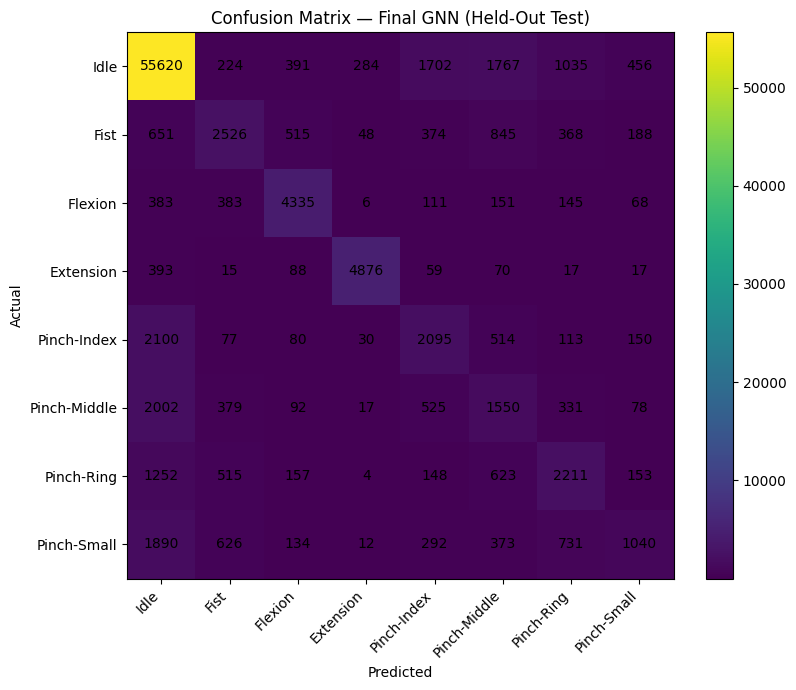

Saved: /kaggle/working/task3_results/final_gnn_test_confusion_matrix.png


In [29]:
# Cell 29 — Required final classification report and confusion matrix

class_names_final = [
    GESTURE_NAMES[int(label)]
    for label in final_gnn_artifacts["le"].classes_
]

print("Final GNN classification report:")
print(
    classification_report(
        gnn_y_true,
        gnn_y_pred,
        target_names=class_names_final,
        zero_division=0,
    )
)

cm = confusion_matrix(
    gnn_y_true,
    gnn_y_pred,
)

fig, ax = plt.subplots(
    figsize=(9, 7)
)

image = ax.imshow(cm)

ax.set_xticks(
    np.arange(len(class_names_final))
)
ax.set_yticks(
    np.arange(len(class_names_final))
)

ax.set_xticklabels(
    class_names_final,
    rotation=45,
    ha="right",
)
ax.set_yticklabels(
    class_names_final,
)

ax.set_title(
    "Confusion Matrix — Final GNN (Held-Out Test)"
)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            int(cm[i, j]),
            ha="center",
            va="center",
        )

plt.colorbar(
    image,
    ax=ax,
    fraction=0.046,
    pad=0.04,
)

plt.tight_layout()

CM_PATH = OUTPUT_FOLDER / "final_gnn_test_confusion_matrix.png"
plt.savefig(
    CM_PATH,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print("Saved:", CM_PATH)


### 8.3 ROC/AUC and Precision-Recall curves


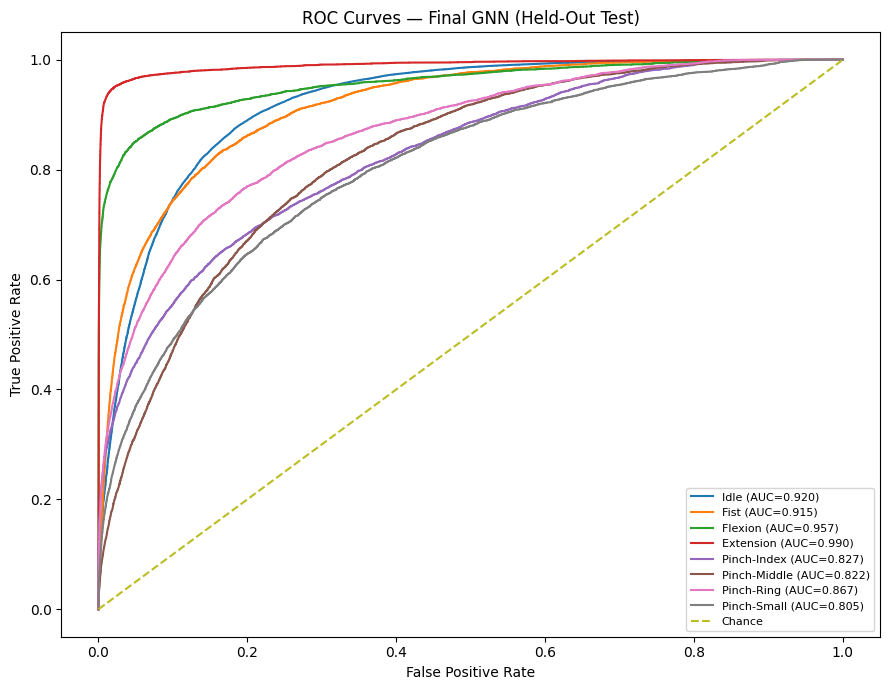

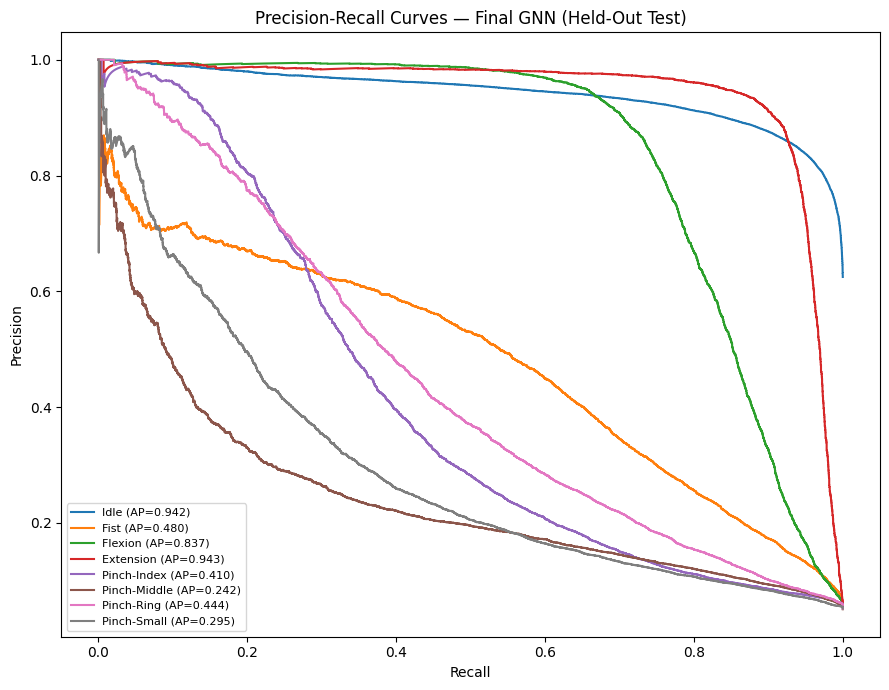

Saved: /kaggle/working/task3_results/final_gnn_test_roc_curves.png
Saved: /kaggle/working/task3_results/final_gnn_test_precision_recall_curves.png


In [30]:
# Cell 30 — Required one-vs-rest ROC and Precision-Recall curves

def plot_multiclass_roc_pr(
    y_true,
    y_score,
    class_names,
    prefix,
):
    y_bin = label_binarize(
        y_true,
        classes=np.arange(len(class_names))
    )

    # ROC
    fig, ax = plt.subplots(
        figsize=(9, 7)
    )

    for i, class_name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(
            y_bin[:, i],
            y_score[:, i],
        )

        auc_i = roc_auc_score(
            y_bin[:, i],
            y_score[:, i],
        )

        ax.plot(
            fpr,
            tpr,
            label=f"{class_name} (AUC={auc_i:.3f})",
        )

    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Chance",
    )

    ax.set_title(
        "ROC Curves — Final GNN (Held-Out Test)"
    )
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(fontsize=8)

    plt.tight_layout()

    roc_path = OUTPUT_FOLDER / f"{prefix}_roc_curves.png"

    plt.savefig(
        roc_path,
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

    # Precision-Recall
    fig, ax = plt.subplots(
        figsize=(9, 7)
    )

    for i, class_name in enumerate(class_names):
        precision_curve, recall_curve, _ = precision_recall_curve(
            y_bin[:, i],
            y_score[:, i],
        )

        ap_i = average_precision_score(
            y_bin[:, i],
            y_score[:, i],
        )

        ax.plot(
            recall_curve,
            precision_curve,
            label=f"{class_name} (AP={ap_i:.3f})",
        )

    ax.set_title(
        "Precision-Recall Curves — Final GNN (Held-Out Test)"
    )
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend(fontsize=8)

    plt.tight_layout()

    pr_path = OUTPUT_FOLDER / f"{prefix}_precision_recall_curves.png"

    plt.savefig(
        pr_path,
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

    print("Saved:", roc_path)
    print("Saved:", pr_path)


plot_multiclass_roc_pr(
    gnn_y_true,
    gnn_y_score,
    class_names_final,
    prefix="final_gnn_test",
)


## 9. Related-work numerical comparison


In [31]:
# Cell 31 — Related-work numerical context
#
# These are verified putEMG-specific numbers supplied in the project review.
# They are NOT statistically compared with our model because the protocols differ.

related_work_df = pd.DataFrame([
    {
        "Study": "Kaczmarek et al. (2019)",
        "Reported putEMG accuracy (%)": 90.0,
        "Classes": "8",
        "Protocol note": "participant/day-specific 3-fold by trials; not unseen-subject",
    },
    {
        "Study": "Falcon-Caro & Sanei (2023)",
        "Reported putEMG accuracy (%)": 86.4,
        "Classes": "7 active gestures",
        "Protocol note": "30-subject DTF result; unseen-subject protocol not clearly established",
    },
    {
        "Study": "SparseEMG / Kumar et al. (2025)",
        "Reported putEMG accuracy (%)": 87.02,
        "Classes": "7 selected gestures",
        "Protocol note": "single-session/user-dependent VR scenario",
    },
])

final_test_accuracy_pct = (
    100.0
    * final_gnn_test_metrics["Accuracy"]
)

related_work_df[
    "Final-GNN raw accuracy difference (pp)"
] = (
    final_test_accuracy_pct
    - related_work_df[
        "Reported putEMG accuracy (%)"
    ]
)

print(
    f"Final GNN held-out unseen-subject accuracy: "
    f"{final_test_accuracy_pct:.2f}%"
)

display(
    related_work_df
)

print(
    "The difference column is a numerical context only. "
    "No 'beat/match/below' verdict is assigned because the published protocols "
    "are not the same as this subject-independent held-out evaluation."
)

related_work_df.to_csv(
    OUTPUT_FOLDER / "related_work_numerical_context.csv",
    index=False,
)


Final GNN held-out unseen-subject accuracy: 75.46%


,Study,Reported putEMG accuracy (%),Classes,Protocol note,Final-GNN raw accuracy difference (pp)
0,Kaczmarek et al. (2019),90.00,8,participant/day-specific 3-fold by trials; not...,-14.543468
1,Falcon-Caro & Sanei (2023),86.40,7 active gestures,30-subject DTF result; unseen-subject protocol...,-10.943468
2,SparseEMG / Kumar et al. (2025),87.02,7 selected gestures,single-session/user-dependent VR scenario,-11.563468


The difference column is a numerical context only. No 'beat/match/below' verdict is assigned because the published protocols are not the same as this subject-independent held-out evaluation.


## 10. Save final Task-3 artifacts


In [32]:
# Cell 32 — Save final artifacts for report + explainability notebook

import joblib

final_graph = final_gnn_artifacts["graph"]

torch.save(
    {
        "model_state_dict": final_gnn_artifacts["best_state"],
        "config": final_config,

        "edge_index": final_graph["edge_index"].cpu(),
        "edge_weight": final_graph["edge_weight"].cpu(),

        "graph_method": final_graph["method"],
        "top_k": final_graph["top_k"],
        "edge_weight_mode": final_graph["edge_weight_mode"],

        "adjacency": final_graph["adjacency"],
        "score_matrix": final_graph["score_matrix"],

        "feature_columns": feat_cols_7,
        "label_classes": [
            int(x)
            for x in final_gnn_artifacts["le"].classes_
        ],

        "validation_metrics": final_val_metrics,
        "test_metrics": final_gnn_test_metrics,
    },
    MODELS_FOLDER / "final_gnn_model.pth",
)

joblib.dump(
    {
        "variance_threshold": final_gnn_artifacts["vt"],
        "robust_scaler": final_gnn_artifacts["scaler"],
        "label_encoder": final_gnn_artifacts["le"],
        "feature_columns": feat_cols_7,
    },
    MODELS_FOLDER / "final_gnn_preprocessing.joblib",
)

original_true_labels = final_gnn_artifacts["le"].inverse_transform(
    gnn_y_true
)
original_pred_labels = final_gnn_artifacts["le"].inverse_transform(
    gnn_y_pred
)

prediction_records = {
    "row_index_in_test_df": np.arange(len(test_df)),
    "subject_id": test_df["subject_id"].to_numpy(),
    "true_label": original_true_labels,
    "pred_label": original_pred_labels,
    "correct": (
        original_true_labels
        == original_pred_labels
    ),
}

for metadata_col in [
    "source_zip",
    "source_csv",
    "experiment_type",
    "segment_id",
    "window_start",
]:
    if metadata_col in test_df.columns:
        prediction_records[
            metadata_col
        ] = test_df[
            metadata_col
        ].to_numpy()

predictions_df = pd.DataFrame(
    prediction_records
)

for i, label_value in enumerate(
    final_gnn_artifacts["le"].classes_
):
    class_name = GESTURE_NAMES[
        int(label_value)
    ]

    predictions_df[
        f"proba_{class_name}"
    ] = gnn_y_score[:, i]

predictions_df.to_csv(
    OUTPUT_FOLDER / "final_gnn_test_predictions.csv",
    index=False,
)

summary = {
    "task2_best_baseline": {
        "model": best_baseline_name,
        "task2_validation_macro_f1": best_baseline_task2_f1,
        "saved_config": best_baseline_config,
    },

    "task2_first_gnn": {
        "model": "MI-GraphSAGE",
        "rerun_validation_metrics": first_task2_validation_metrics,
        "config": TASK2_FIRST_CONFIG,
    },

    "final_config": final_config,

    "ablation_stage_summary": stage_summary_df.to_dict(
        "records"
    ),

    "cv_summary": cv_summary_df.to_dict(
        "records"
    ),

    "wilcoxon": wilcoxon_result,

    "heldout_test_comparison": heldout_test_df.to_dict(
        "records"
    ),
}

with open(
    OUTPUT_FOLDER / "task3_summary.json",
    "w",
) as f:
    json.dump(
        summary,
        f,
        indent=2,
        default=lambda x: (
            x.item()
            if hasattr(x, "item")
            else str(x)
        ),
    )

print("Saved:", MODELS_FOLDER / "final_gnn_model.pth")
print("Saved:", MODELS_FOLDER / "final_gnn_preprocessing.joblib")
print("Saved:", OUTPUT_FOLDER / "final_gnn_test_predictions.csv")
print("Saved:", OUTPUT_FOLDER / "task3_summary.json")
print(
    "Task-3 improvement outputs are saved. "
    "SHAP + LIME remains a separate required explainability notebook."
)

# Convenience archive: easy to download or upload as a persistent Kaggle Dataset.
import shutil
archive_path = shutil.make_archive(
    "/kaggle/working/task3_resume_artifacts",
    "zip",
    root_dir="/kaggle/working",
    base_dir="task3_results",
)
print("Saved resume archive:", archive_path)


Saved: /kaggle/working/models/final_gnn_model.pth
Saved: /kaggle/working/models/final_gnn_preprocessing.joblib
Saved: /kaggle/working/task3_results/final_gnn_test_predictions.csv
Saved: /kaggle/working/task3_results/task3_summary.json
Task-3 improvement outputs are saved. SHAP + LIME remains a separate required explainability notebook.
Saved resume archive: /kaggle/working/task3_resume_artifacts.zip
